Missing metrics (bars would be zero): []


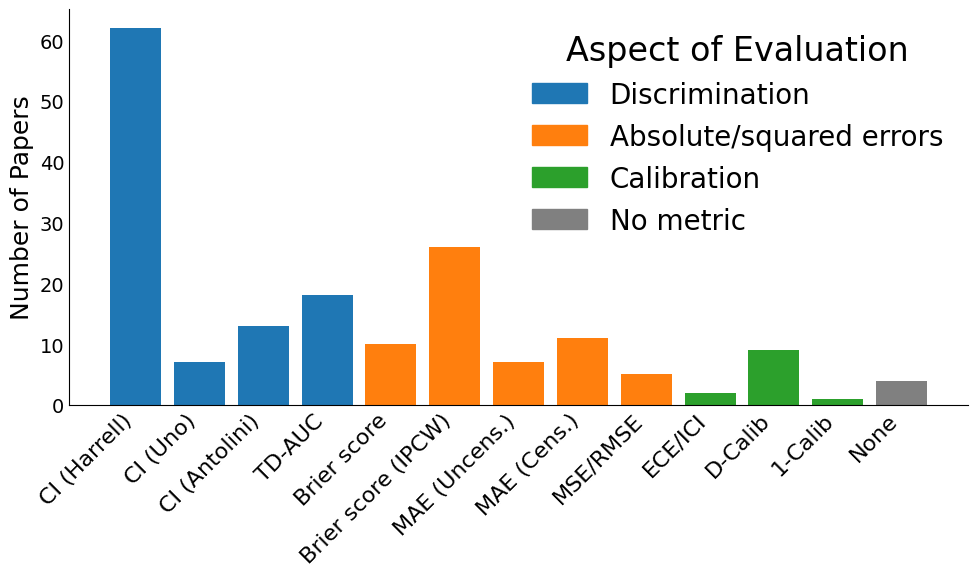

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

matplotlib_style = 'default'
plt.style.use(matplotlib_style)
plt.rcParams.update({
    'axes.labelsize': 'large',
    'axes.titlesize': 'large',
    'xtick.labelsize': 'large',
    'font.size': 14.0,
    'legend.fontsize': 'large'
})

# Load data
df = pd.read_csv('data/metrics_used.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Count non-empty values per metric, excluding the title column
metric_counts = df.iloc[:, 1:].apply(
    lambda col: col.astype(str).str.strip().replace("nan", "").ne("")
).sum()

# Create the new combined metric 'MAE (Cens.)'
mae_cens_sum = (
    metric_counts.get("MAE (Hinge)", 0)
    + metric_counts.get("MAE (Margin)", 0)
    + metric_counts.get("MAE (PO)", 0)
)

# Remove the three original MAE metrics
metric_counts = metric_counts.drop(
    ["MAE (Hinge)", "MAE (Margin)", "MAE (PO)"],
    errors='ignore'
)

# Add the combined metric
metric_counts["MAE (Cens.)"] = mae_cens_sum

# Define categories
categories = {
    "Discrimination": [
        "CI (Harrell)",
        "CI (Uno)",
        "CI (Antolini)",
        "TD-AUC"
    ],
    "Absolute/squared errors": [
        "Brier score",
        "Brier score (IPCW)",
        "MAE (Uncens.)",
        "MAE (Cens.)",
        "MSE/RMSE"
    ],
    "Calibration": [
        "ECE/ICI",
        "D-Calib",
        "1-Calib"
    ],
    "No metric": [
        "None"
    ]
}

# Define category colors
category_colors = {
    "Discrimination": "tab:blue",
    "Absolute/squared errors": "tab:orange",
    "Calibration": "tab:green",
    "No metric": "gray"
}

# Flatten to map each metric to its category and color
metric_to_category = {
    metric: cat
    for cat, metrics in categories.items()
    for metric in metrics
}

metric_to_color = {
    metric: category_colors[metric_to_category[metric]]
    for metric in metric_counts.index
    if metric in metric_to_category
}

# Sort metrics by category for grouped plotting
sorted_metrics = sum(categories.values(), [])

# Plot only valid metrics
existing_metrics = [m for m in sorted_metrics if m in metric_counts.index]
missing_metrics = [m for m in sorted_metrics if m not in metric_counts.index]

print("Missing metrics (bars would be zero):", missing_metrics)

sorted_metrics = existing_metrics

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    sorted_metrics,
    [metric_counts.get(m, 0) for m in sorted_metrics],
    color=[metric_to_color.get(m, "gray") for m in sorted_metrics]
)

# Remove plot borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend handles
legend_handles = [
    Patch(color=color, label=cat)
    for cat, color in category_colors.items()
]

plt.legend(
    handles=legend_handles,
    title="Aspect of Evaluation",
    frameon=False,
    fontsize=20,
    title_fontsize=24
)

# Labeling
plt.ylabel("Number of Papers", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.tick_params(axis='x', which='both', length=0)
plt.tick_params(axis='y', which='both', length=0)
plt.tight_layout()
plt.savefig("plots/metrics_used.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 1000x700 with 0 Axes>

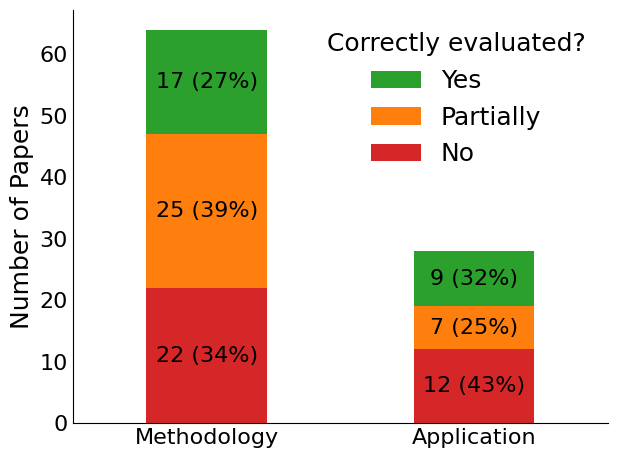

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# LOAD + CLEAN DATA
# -------------------------
df = pd.read_csv("data/correct_evaluation.csv", dtype=str)

# Clean title column
df["Title"] = df["Title"].astype(str).str.strip()

# Filter out year-header rows and blank rows
mask = (
    df["Title"].notna() &
    (df["Title"] != "") &
    ~df["Title"].str.match(r"^20\d{2},*$") &
    ~df["Title"].str.match(r"^,*$")
)
df = df[mask]

# Extract evaluation table
df_eval = df[["Problem type", "Metrics Match Objectives?"]].copy()

# Normalize text fields
df_eval["Problem type"] = df_eval["Problem type"].str.strip()
df_eval["Metrics Match Objectives?"] = (
    df_eval["Metrics Match Objectives?"]
    .str.strip()
    .str.split(",", n=1).str[0]  # remove explanatory text
    .str.capitalize()
)

# -------------------------
# GROUPING
# -------------------------
counts = (
    df_eval.groupby(["Problem type", "Metrics Match Objectives?"])
    .size()
    .unstack(fill_value=0)
)

# Ensure fixed order
counts = counts.reindex(["Methodology", "Application"])

# Percentages per row
pct = counts.div(counts.sum(axis=1), axis=0) * 100

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(10,7))
ax = counts.plot(
    kind="bar",
    stacked=True,
    color={"Yes": "tab:green", "No": "tab:red", "Partially": "tab:orange"},
    fontsize=16
)

# Manually reorder legend entries: bottom = No, then Partially, then Yes
handles, labels = ax.get_legend_handles_labels()

# Mapping from label to handle
hmap = dict(zip(labels, handles))

ordered_labels = ["Yes", "Partially", "No"]
ordered_handles = [hmap[l] for l in ordered_labels if l in hmap]

ax.legend(
    ordered_handles,
    ordered_labels,
    title="Correctly evaluated?",
    frameon=False,
    fontsize=18,
    title_fontsize=18
)

# Remove extraneous borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -------------------------
# NARROW THE BARS (TRUE FIX)
# -------------------------
desired_width = 0.45
for bar in ax.patches:
    full_width = bar.get_width()
    shift = (full_width - desired_width) / 2
    bar.set_width(desired_width)
    bar.set_x(bar.get_x() + shift)

# -------------------------
# LABELS + TICK STYLING
# -------------------------
plt.ylabel("Number of Papers", fontsize=18)
plt.xlabel("", fontsize=18)
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.tick_params(axis='x', length=0)
plt.tick_params(axis='y', length=0)

# -------------------------
# ADD LABELS TO EACH SECTION
# -------------------------
for i, (ptype, row) in enumerate(counts.iterrows()):
    cumulative = 0
    for outcome in ["No", "Partially", "Yes"]:
        value = row.get(outcome, 0)
        if value > 0:
            percent = pct.loc[ptype, outcome]
            label = f"{value} ({percent:.0f}%)"
            ax.text(
                i,
                cumulative + value/2,
                label,
                ha="center",
                va="center",
                fontsize=16,
                color="black"
            )
        cumulative += value

plt.tight_layout()
plt.savefig("plots/metrics_correctness.pdf", format="pdf", bbox_inches="tight")
plt.show()